In [39]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import networkx as nx

PROJECT_DIR = "/content/drive/MyDrive/Cancer Evolution Arena"
DATA_DIR = f"{PROJECT_DIR}/Data"
RESULTS_DIR = f"{DATA_DIR}/Results"

progression_path = f"{RESULTS_DIR}/notebook07_inferred_progression_edges.csv"

print(os.path.exists(progression_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True


In [40]:
!pip install pyvis

In [41]:
from pyvis.network import Network

progression_edges = pd.read_csv(progression_path)
progression_edges.head()

,From,To,P_From,P_To,P_To_given_From,P_To_given_Not_From,Probability_Gain,CoOccurrence,OddsRatio,PValue
0,ATR,NTRK2,0.047826,0.043478,0.272727,0.031963,0.240764,3,11.357143,0.008194
1,BRAF,PIK3CA,0.095652,0.073913,0.272727,0.052885,0.219843,6,6.715909,0.002373
2,ALK,NTRK3,0.100000,0.091304,0.260870,0.072464,0.188406,6,4.517647,0.010199
3,ERBB4,SMARCA4,0.100000,0.056522,0.217391,0.038647,0.178744,5,6.909722,0.004841
4,NF1,NTRK3,0.130435,0.091304,0.233333,0.070000,0.163333,7,4.043478,0.010019


In [42]:
G = nx.DiGraph()

ecosystem_groups = {
    "KRAS": "KRAS Ecosystem",
    "STK11": "KRAS Ecosystem",
    "KEAP1": "KRAS Ecosystem",
    "RBM10": "KRAS Ecosystem",
    "ATM": "KRAS Ecosystem",

    "EGFR": "EGFR Ecosystem",

    "TP53": "TP53/NF1 Ecosystem",
    "NF1": "TP53/NF1 Ecosystem",
    "ALK": "TP53/NF1 Ecosystem",
    "CDKN2A": "TP53/NF1 Ecosystem",

    "BRAF": "BRAF/PIK3CA Ecosystem",
    "PIK3CA": "BRAF/PIK3CA Ecosystem",

    "ERBB4": "ERBB4/SMARCA4 Ecosystem",
    "SMARCA4": "ERBB4/SMARCA4 Ecosystem"
}

for _, row in progression_edges.iterrows():
    source = row["From"]
    target = row["To"]

    G.add_node(
        source,
        group=ecosystem_groups.get(source, "Other"),
        title=f"{source}<br>Ecosystem: {ecosystem_groups.get(source, 'Other')}"
    )

    G.add_node(
        target,
        group=ecosystem_groups.get(target, "Other"),
        title=f"{target}<br>Ecosystem: {ecosystem_groups.get(target, 'Other')}"
    )

    G.add_edge(
        source,
        target,
        weight=row["Probability_Gain"],
        odds_ratio=row["OddsRatio"],
        p_value=row["PValue"],
        cooccurrence=row["CoOccurrence"],
        title=(
            f"{source} → {target}<br>"
            f"Probability Gain: {row['Probability_Gain']:.3f}<br>"
            f"Odds Ratio: {row['OddsRatio']:.2f}<br>"
            f"p-value: {row['PValue']:.4f}<br>"
            f"Co-occurrence: {row['CoOccurrence']}"
    ),
    llabel=f"{row['Probability_Gain']:.2f}"
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 30
Edges: 32


In [43]:
net = Network(
    notebook=True,
    cdn_resources="remote",
    directed=True,
    height="750px",
    width="100%",
    heading="Cancer Evolution Arena: Inferred Tumor Progression Map"
)

net.from_nx(G)

net.repulsion(
    node_distance=180,
    central_gravity=0.2,
    spring_length=200,
    spring_strength=0.05
)

output_path = f"{RESULTS_DIR}/cancer_evolution_arena_macro_map.html"
net.show(output_path)

output_path

/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/cancer_evolution_arena_macro_map.html


'/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/cancer_evolution_arena_macro_map.html'

In [44]:
def build_driver_subgraph(start_gene, max_depth=2):
    sub_nodes = set([start_gene])
    frontier = {start_gene}

    for _ in range(max_depth):
        next_frontier = set()

        for node in frontier:
            if node in G:
                successors = list(G.successors(node))
                next_frontier.update(successors)

        sub_nodes.update(next_frontier)
        frontier = next_frontier

    return G.subgraph(sub_nodes).copy()

In [45]:
G_kras = build_driver_subgraph("KRAS", max_depth=2)

net_kras = Network(
    notebook=True,
    directed=True,
    height="650px",
    width="100%",
    cdn_resources="remote",
    heading="KRAS Ecosystem Branching Forecast"
)

net_kras.from_nx(G_kras)

net_kras.repulsion(
    node_distance=180,
    central_gravity=0.2,
    spring_length=200,
    spring_strength=0.05
)

kras_path = f"{RESULTS_DIR}/kras_branching_forecast.html"
net_kras.save_graph(kras_path)

from IPython.display import IFrame

IFrame(
    src=kras_path,
    width=1000,
    height=700
)

kras_path

'/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/kras_branching_forecast.html'

In [46]:
import os

os.path.exists(
    "/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/kras_branching_forecast.html"
)

True

In [47]:
# Full Cancer Evolution Arena Map

net_full = Network(
    notebook=True,
    cdn_resources="remote",
    directed=True,
    height="750px",
    width="100%",
    heading="Cancer Evolution Arena: Global Tumor Progression Map"
)

net_full.from_nx(G)

net_full.repulsion(
    node_distance=220,
    central_gravity=0.2,
    spring_length=220,
    spring_strength=0.05
)

full_path = f"{RESULTS_DIR}/global_cancer_evolution_arena.html"

net_full.save_graph(full_path)

from IPython.display import IFrame

IFrame(
    src=full_path,
    width=1100,
    height=750
)

In [48]:
def save_driver_forecast(start_gene, max_depth=2):
    G_sub = build_driver_subgraph(start_gene, max_depth=max_depth)

    net = Network(
        notebook=True,
        cdn_resources="remote",
        directed=True,
        height="650px",
        width="100%",
        heading=f"{start_gene} Ecosystem Branching Forecast"
    )

    net.from_nx(G_sub)

    net.repulsion(
        node_distance=180,
        central_gravity=0.2,
        spring_length=200,
        spring_strength=0.05
    )

    path = f"{RESULTS_DIR}/{start_gene.lower()}_branching_forecast.html"
    net.save_graph(path)

    return path

In [49]:
driver_paths = {}

for gene in ["KRAS", "TP53", "BRAF", "ERBB4"]:
    driver_paths[gene] = save_driver_forecast(gene, max_depth=2)

driver_paths

{'KRAS': '/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/kras_branching_forecast.html',
 'TP53': '/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/tp53_branching_forecast.html',
 'BRAF': '/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/braf_branching_forecast.html',
 'ERBB4': '/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/erbb4_branching_forecast.html'}

In [50]:
IFrame(
    src=driver_paths["TP53"],
    width=1100,
    height=700
)

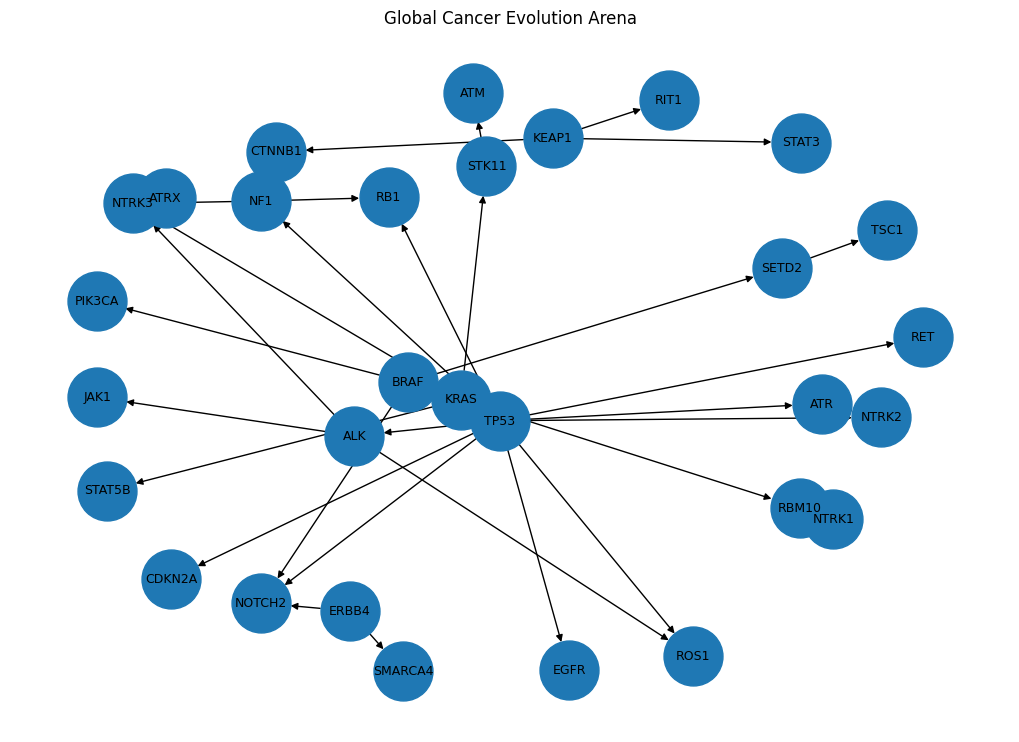

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    arrows=True,
    font_size=9
)

plt.title("Global Cancer Evolution Arena")
plt.show()

In [52]:
ecosystem_labels = {
    "KRAS": "KRAS Ecosystem",
    "STK11": "KRAS Ecosystem",
    "RBM10": "KRAS Ecosystem",
    "ATM": "KRAS Ecosystem",
    "STAT5B": "KRAS Ecosystem",

    "KEAP1": "KEAP1/WNT-Immune Ecosystem",
    "CTNNB1": "KEAP1/WNT-Immune Ecosystem",
    "STAT3": "KEAP1/WNT-Immune Ecosystem",
    "RIT1": "KEAP1/WNT-Immune Ecosystem",

    "TP53": "TP53 Hub Ecosystem",
    "NF1": "TP53 Hub Ecosystem",
    "ALK": "TP53 Hub Ecosystem",
    "EGFR": "TP53 Hub Ecosystem",
    "CDKN2A": "TP53 Hub Ecosystem",
    "RET": "TP53 Hub Ecosystem",
    "NTRK2": "TP53 Hub Ecosystem",
    "ROS1": "TP53 Hub Ecosystem",

    "BRAF": "MAPK/PI3K Ecosystem",
    "PIK3CA": "MAPK/PI3K Ecosystem",
    "NOTCH2": "MAPK/PI3K Ecosystem",
    "SETD2": "MAPK/PI3K Ecosystem",

    "ERBB4": "ERBB4/Chromatin Ecosystem",
    "SMARCA4": "ERBB4/Chromatin Ecosystem"
}

In [53]:
import pandas as pd

patient_gene = pd.read_csv(
    f"{DATA_DIR}/patient_gene_matrix.csv",
    index_col=0
)

patient_gene.head()

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,snoU13
Tumor_Sample_Barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-05-4249-01,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4382-01,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4384-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4389-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4390-01,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [54]:
gene_prevalence = patient_gene.mean().to_dict()

for node in G.nodes():
    prevalence = gene_prevalence.get(node, 0)
    G.nodes[node]["size"] = 15 + prevalence * 80
    G.nodes[node]["group"] = ecosystem_labels.get(node, "Other")
    G.nodes[node]["title"] = (
        f"<b>{node}</b><br>"
        f"Ecosystem: {ecosystem_labels.get(node, 'Other')}<br>"
        f"Prevalence: {prevalence:.2%}"
    )

In [55]:
for u, v, data in G.edges(data=True):
    data["title"] = (
        f"<b>{u} → {v}</b><br>"
        f"Progression Gain: {data.get('weight', 0):.3f}<br>"
        f"Odds Ratio: {data.get('odds_ratio', 0):.2f}<br>"
        f"p-value: {data.get('p_value', 0):.4f}<br>"
        f"Co-occurrence: {data.get('cooccurrence', 0)} patients"
    )
    data["label"] = f"{data.get('weight', 0):.2f}"
    data["width"] = 1 + data.get("weight", 0) * 12

In [56]:
from pyvis.network import Network

net_arena = Network(
    notebook=True,
    cdn_resources="remote",
    directed=True,
    height="800px",
    width="100%",
    heading="Cancer Evolution Arena: Ecosystem-Annotated Tumor Progression Map"
)

net_arena.from_nx(G)

net_arena.repulsion(
    node_distance=230,
    central_gravity=0.15,
    spring_length=250,
    spring_strength=0.04
)

arena_path = f"{RESULTS_DIR}/ecosystem_annotated_cancer_evolution_arena.html"
net_arena.save_graph(arena_path)

arena_path

'/content/drive/MyDrive/Cancer Evolution Arena/Data/Results/ecosystem_annotated_cancer_evolution_arena.html'